<a href="https://colab.research.google.com/github/Goldeno10/flexisaf_Internship_GenAI_DS_Intermediate/blob/main/task_4/Image_Captioning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pickle
import torch
from torch import nn
import numpy as np
from tqdm import tqdm


device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/adityajn105/flickr8k")

Skipping, found downloaded files in "./flickr8k" (use force=True to force download)


In [ ]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("adityajn105/flickr8k")
# # path = kagglehub.dataset_download("adityajn105/flickr30k")

# print("Path to dataset files:", path)

In [ ]:
import torchvision.transforms as transforms


# Define the transform pipeline
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],    # Standard ImageNet mean
        std=[0.229, 0.224, 0.225]      # Standard ImageNet std
    )
])


In [ ]:
import torch
from collections import Counter


class Vocabulary:
    """
    handles word-to-index mapping and should be saved as
    a .pkl file so you can swap it when changing datasets.
    """
    def __init__(self, freq_threshold):
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {v: k for k, v in self.itos.items()}
        self.freq_threshold = freq_threshold

    def build_vocabulary(self, sentence_list):
        """Build the vocabulary from a list of sentences."""
        frequencies = Counter()
        idx = 4
        for sentence in sentence_list:
            for word in sentence.lower().split():
                frequencies[word] += 1
                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self, text):
        tokenized_text = text.lower().split()
        return [self.stoi.get(token, self.stoi["<UNK>"]) for token in tokenized_text]


In [ ]:
import os
import torch
from PIL import Image
from torch.utils.data import Dataset
from torch.nn.utils.rnn import pad_sequence


class ImageCaptionDataset(Dataset):
    """Dataset with flexible loading for Flickr8k/30k/MS COCO."""
    def __init__(self, root_dir, captions_df, transform=None, vocab=None):
        self.root_dir = root_dir
        self.df = captions_df
        self.transform = transform
        self.vocab = vocab

    def __len__(self): return len(self.df)

    def __getitem__(self, index):
        caption = self.df["caption"][index]
        img_id = self.df["image"][index]
        img = Image.open(os.path.join(self.root_dir, img_id)).convert("RGB")

        if self.transform:
            img = self.transform(img)

        # Numericalize caption and add start/end tokens
        numericalized_caption = [self.vocab.stoi["<SOS>"]]
        numericalized_caption += self.vocab.numericalize(caption)
        numericalized_caption += [self.vocab.stoi["<EOS>"]]

        return img, torch.tensor(numericalized_caption)



class MyCollate:
    """Pads batches dynamically."""
    def __init__(self, pad_idx): self.pad_idx = pad_idx

    def __call__(self, batch):
        imgs = torch.stack([item[0] for item in batch])
        targets = pad_sequence([item[1] for item in batch], batch_first=True, padding_value=self.pad_idx)
        return imgs, targets


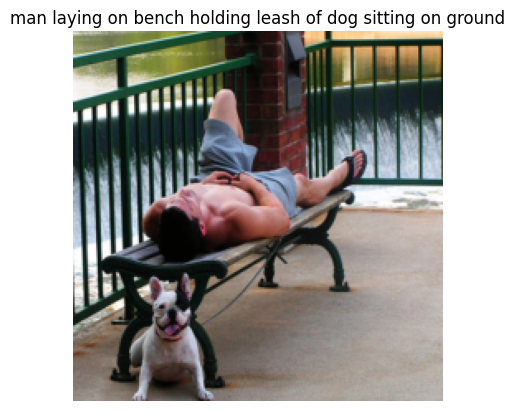

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def show_example(dataset, idx):
    # 1. Get the item from dataset
    img, caption = dataset[idx]

    # 2. Denormalize the image for display
    # (Multiply by std and add mean)
    img_display = img.permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_display = std * img_display + mean
    img_display = np.clip(img_display, 0, 1) # Ensure values are 0-1

    # 3. Convert word indices back to strings
    readable_caption = [dataset.vocab.itos[token.item()] for token in caption]
    # Remove <PAD>, <SOS>, <EOS> for a cleaner look
    clean_caption = " ".join([w for w in readable_caption if w not in ["<PAD>", "<SOS>", "<EOS>"]])

    # 4. Plot
    plt.imshow(img_display)
    plt.title(clean_caption)
    plt.axis("off")
    plt.show()


# Read the captions file into a DataFrame
captions_df = pd.read_csv("flickr8k/captions.txt")

# Initialize and build vocabulary
vocab = Vocabulary(freq_threshold=5)
vocab.build_vocabulary(captions_df["caption"].tolist())

dataset = ImageCaptionDataset(
    root_dir="flickr8k/Images",
    captions_df=captions_df,
    transform=transform,
    vocab=vocab
)

show_example(dataset, 19)


In [ ]:
from torchvision import models

class EncoderCNN(nn.Module):
    """
    CNN Encoder Model

    We use a pre-trained ResNet50. We freeze the weights and
    replace the final FC layer with a linear layer that matches our hidden size.
    """
    def __init__(self, embed_size, train_CNN=False):
        super(EncoderCNN, self).__init__()
        self.train_CNN = train_CNN
        self.resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.resnet.fc = nn.Linear(self.resnet.fc.in_features, embed_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, images):
        features = self.resnet(images)
        return self.dropout(self.relu(features))


In [ ]:
class DecoderRNN(nn.Module):
    """This takes the image features and generates word sequences."""
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super(DecoderRNN, self).__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers)
        self.linear = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(0.5)

    def forward(self, features, captions):
        # features shape: [batch, embed_size]
        # captions shape: [batch, seq_len] (from MyCollate with batch_first=True)
        embeddings = self.dropout(self.embed(captions))

        # Prepend the image features to the caption embeddings
        # features.unsqueeze(1) changes [batch, embed_size] to [batch, 1, embed_size]
        # Concatenate along dim=1 (sequence dimension) to get [batch, 1 + seq_len, embed_size]
        embeddings = torch.cat((features.unsqueeze(1), embeddings), dim=1)

        hiddens, _ = self.lstm(embeddings)
        outputs = self.linear(hiddens)
        return outputs

In [ ]:
class CNNtoRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super(CNNtoRNN, self).__init__()
        self.encoderCNN = EncoderCNN(embed_size)
        self.decoderRNN = DecoderRNN(embed_size, hidden_size, vocab_size, num_layers)

    def forward(self, images, captions):
        features = self.encoderCNN(images)
        outputs = self.decoderRNN(features, captions)
        return outputs


In [ ]:
from torch.utils.data import DataLoader

def train(
    embed_size = 256,
    hidden_size = 256,
    num_layers = 1,
    learning_rate = 3e-4,
    num_epochs = 20,
    batch_size = 32
    ):
    vocab_size = len(dataset.vocab.stoi)
    # Initialize model, loss, optimizer
    model = CNNtoRNN(embed_size, hidden_size, vocab_size, num_layers).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=dataset.vocab.stoi["<PAD>"])
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # Initialize DataLoader
    pad_idx = dataset.vocab.stoi["<PAD>"]
    dataloader = DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        num_workers=2,
        shuffle=True,
        collate_fn=MyCollate(pad_idx=pad_idx)
    )

    model.train()
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        for idx, (imgs, captions) in enumerate(dataloader):
            imgs, captions = imgs.to(device), captions.to(device)

            outputs = model(imgs, captions[:, :-1]) # Don't pass <EOS> to decoder

            # Reshape for CrossEntropy: (seq_len * batch, vocab_size)
            # Corrected: Slice outputs to match target sequence length
            loss = criterion(outputs[:, 1:].reshape(-1, outputs.shape[2]), captions[:, 1:].reshape(-1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if idx % 100 == 0:
                print(f"  Batch {idx}/{len(dataloader)}, Loss: {loss.item():.4f}")

    print("Training complete.")

In [ ]:
train()

Epoch 1/20
  Batch 0/1265, Loss: 7.9915
  Batch 100/1265, Loss: 4.7255
